# TTK7 Assignment 1: Analysis of a brainwave signal
> Authored by Sondre Tveiten and Hans G. L. Grayston

Main takeaway: The methods of analysis is limited due to the lack of IMF decomposition.


### Load the timeseries as a Pandas Dataframe type object

In [3]:
import pandas as pd
import numpy as np
from src.signal_analyzer import SignalAnalyzer

df = pd.read_csv('signals/Signal3_2018.csv', header=None)
base_signal = df.iloc[0].values
df_mask = pd.read_csv('signals/signal3_imf_new_final_signal.csv', header=None)
masked_signal = df_mask.iloc[0].values


## 

## The signal at hand

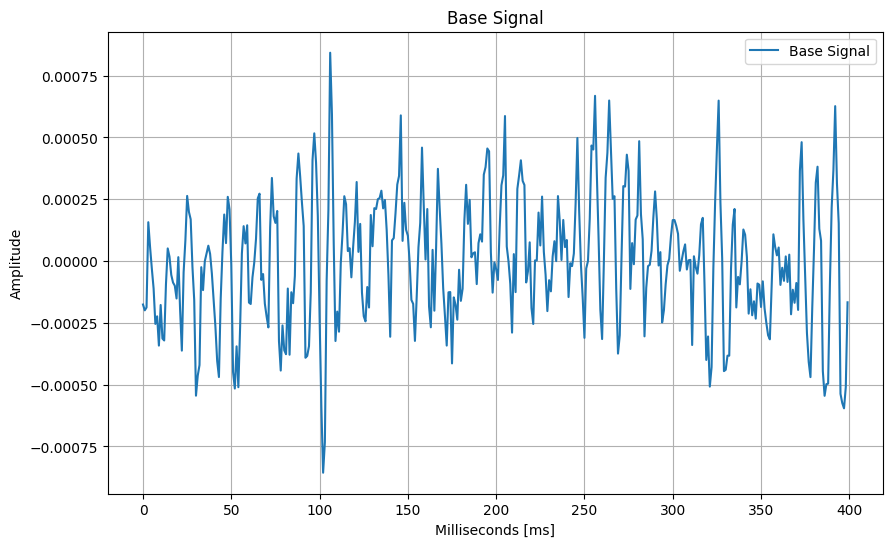

In [4]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(base_signal, label='Base Signal')
plt.title('Base Signal')
plt.xlabel('Milliseconds [ms]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()

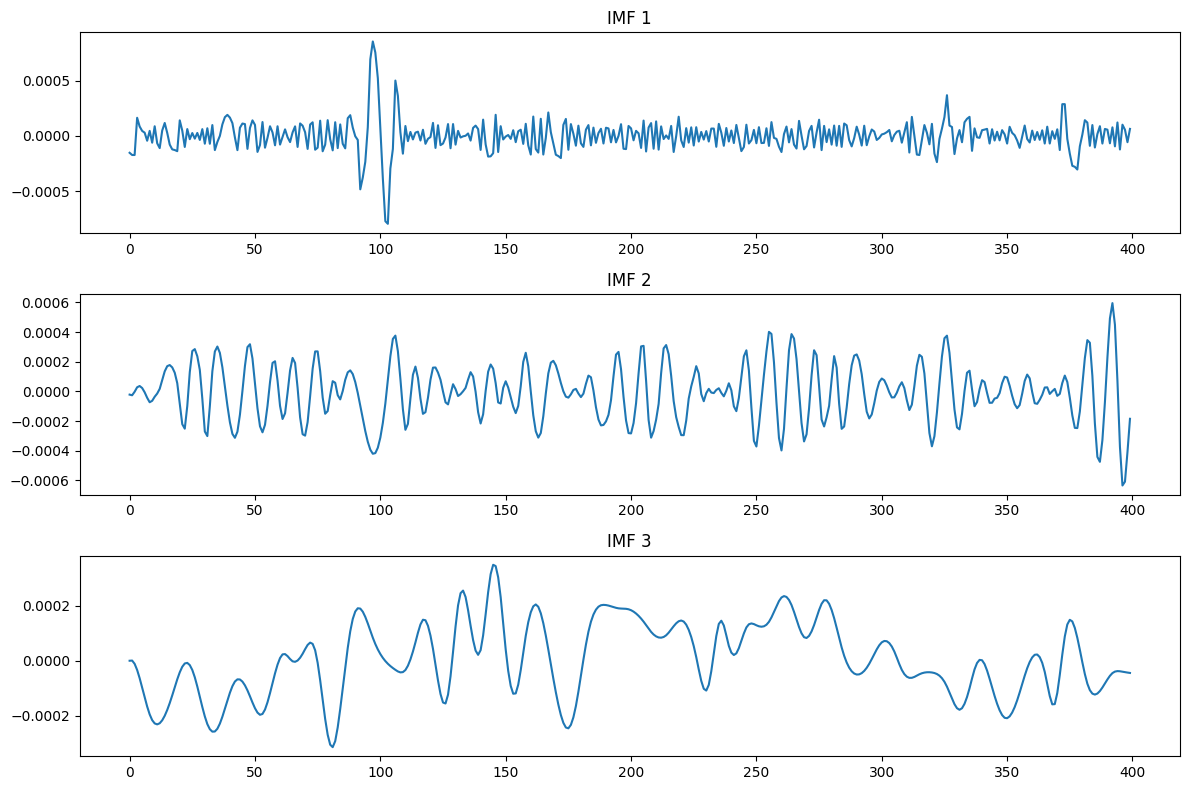

In [5]:
from PyEMD import EMD

# Perform EMD
emd = EMD()
imfs = emd(base_signal)

# Plot the IMFs
plt.figure(figsize=(12, 8))
for i, imf in enumerate(imfs):
    plt.subplot(len(imfs), 1, i + 1)
    plt.plot(imf)
    plt.title(f'IMF {i + 1}')
    plt.tight_layout()
plt.show()

## Which analyses did we opt for?

The Hilbert transform proved to be uninformative for this signal, as there are several modes in the mix. HT expects a single-mode input only, **so we gain nothing on calculating it.** Otherwise, we opted for FFT, STFT, WVT and Wavelet Transform.


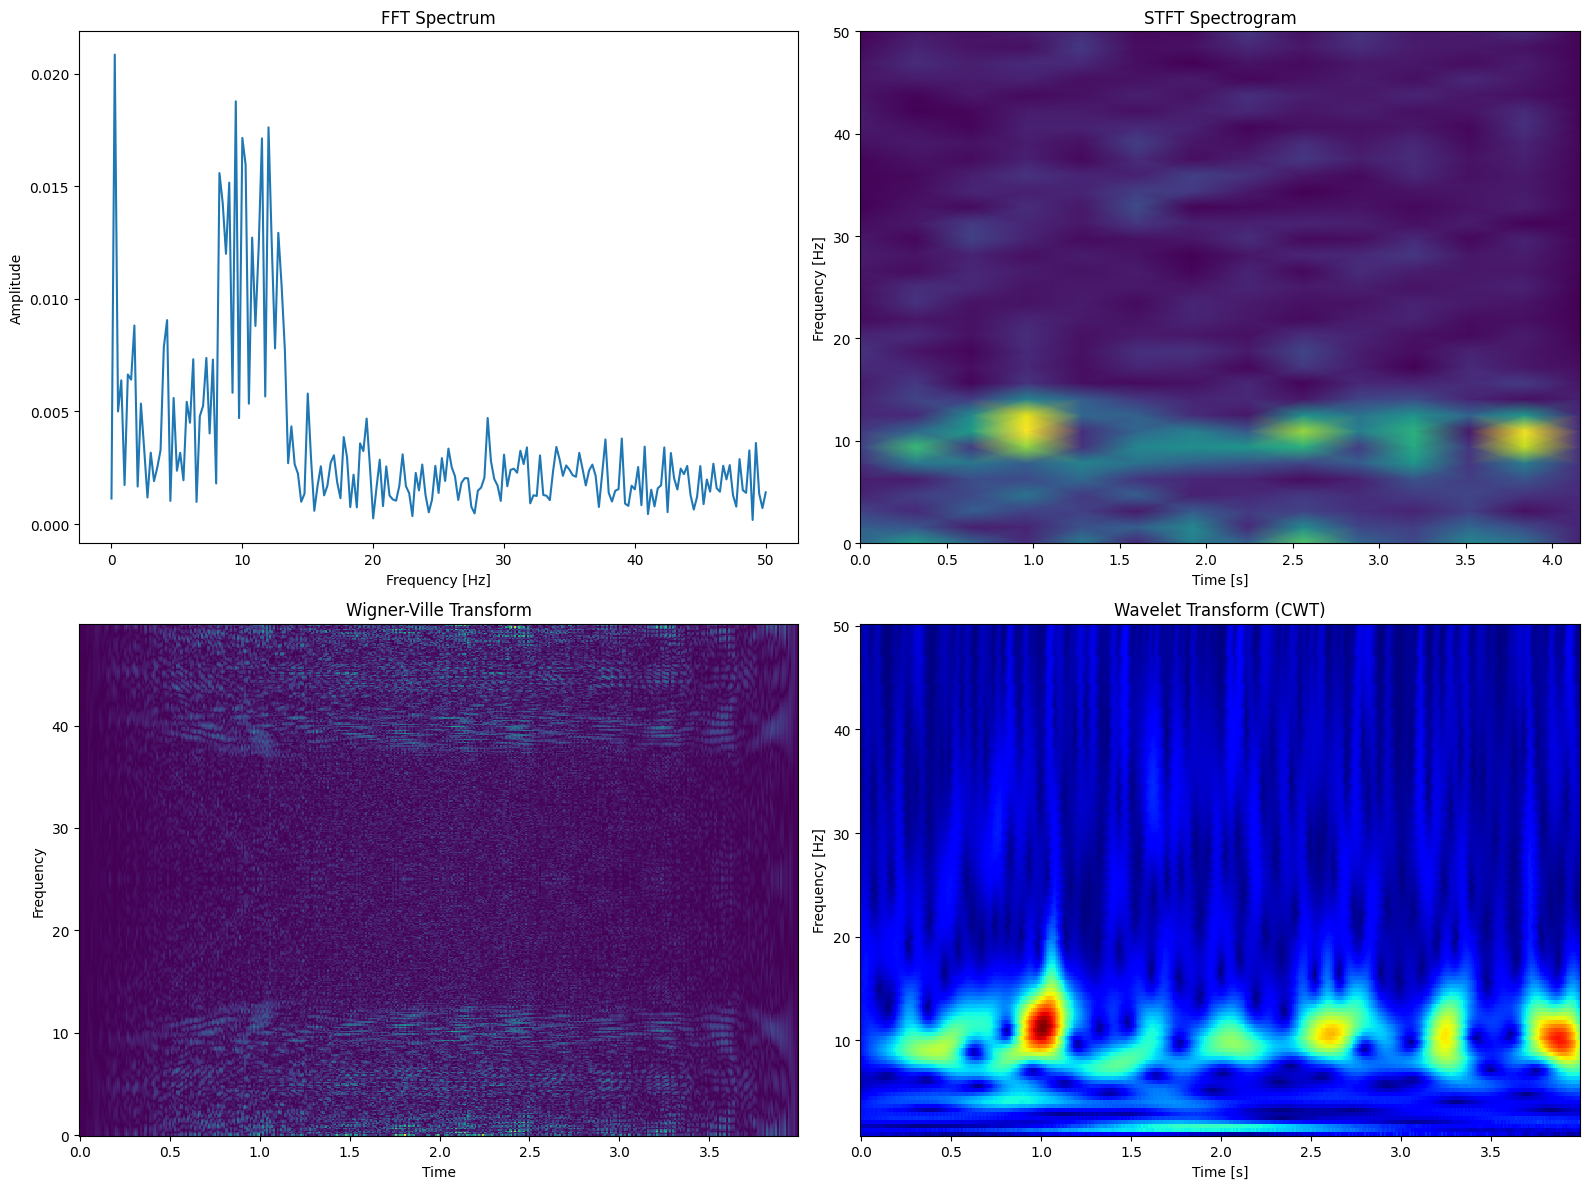

In [13]:
# ht   = SignalAnalyzer.hilbert_transform(signal, fs=100.0, n_bins=256)
analyzer = SignalAnalyzer()
window_size = 64

fft = analyzer.fft_transform(base_signal, fs=100.0)
stft = analyzer.stft_transform(base_signal, fs=100.0, nperseg=window_size)
wvt = analyzer.wvt_transform(base_signal)
cwt = analyzer.wt_transform(base_signal, fs=100.0)

results = [
    fft,
    stft,
    wvt,
    cwt
]

plot_analytical_signal = True
width = 16
height = 12
if plot_analytical_signal:
    analyzer.plot_all(base_signal, results, width, height)

### What do the plots tell us about the signal's stationarity?

> Given the time-varying property of the frequency magnitudes, we can conclude that the signal is non-stationary.

## Does the signal still produce the same signature even after a Gaussian component is added to the modes?

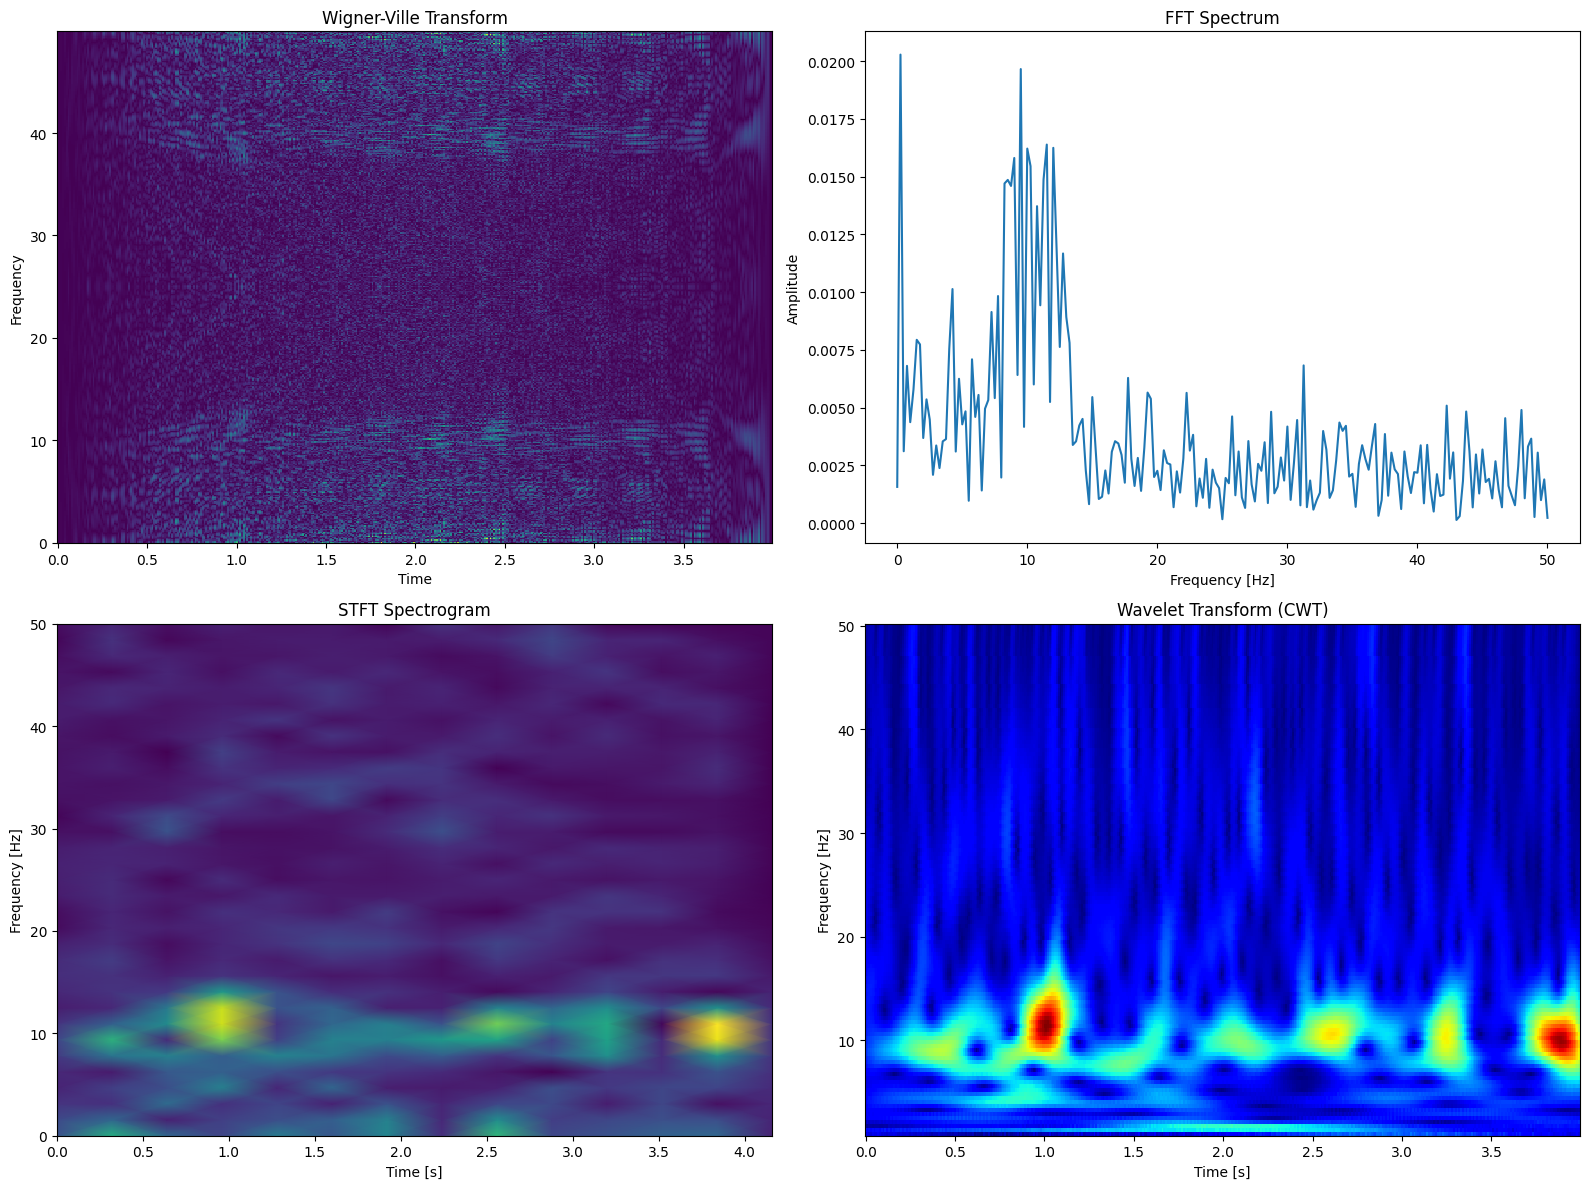

In [14]:
# Add white noise
noise = np.random.normal(0,base_signal.max()/10,len(base_signal))
noisy_signal = base_signal + noise

# ht_noisy   = analyzer.hilbert_transform(noisy_signal, fs=100.0, n_bins=64)
wvt_noisy  = analyzer.wvt_transform(noisy_signal)
fft_noisy  = analyzer.fft_transform(noisy_signal, fs=100.0)
stft_noisy = analyzer.stft_transform(noisy_signal, fs=100.0, nperseg=window_size)
cwt_noisy  = analyzer.wt_transform(noisy_signal, wavelet='cmor1.5-1.0', fs=100.0)
results_noisy = [
    # ht_noisy,
    wvt_noisy,
    fft_noisy,
    stft_noisy,
    cwt_noisy
]
analyzer.plot_all(noisy_signal, results_noisy, width=16, height=12)


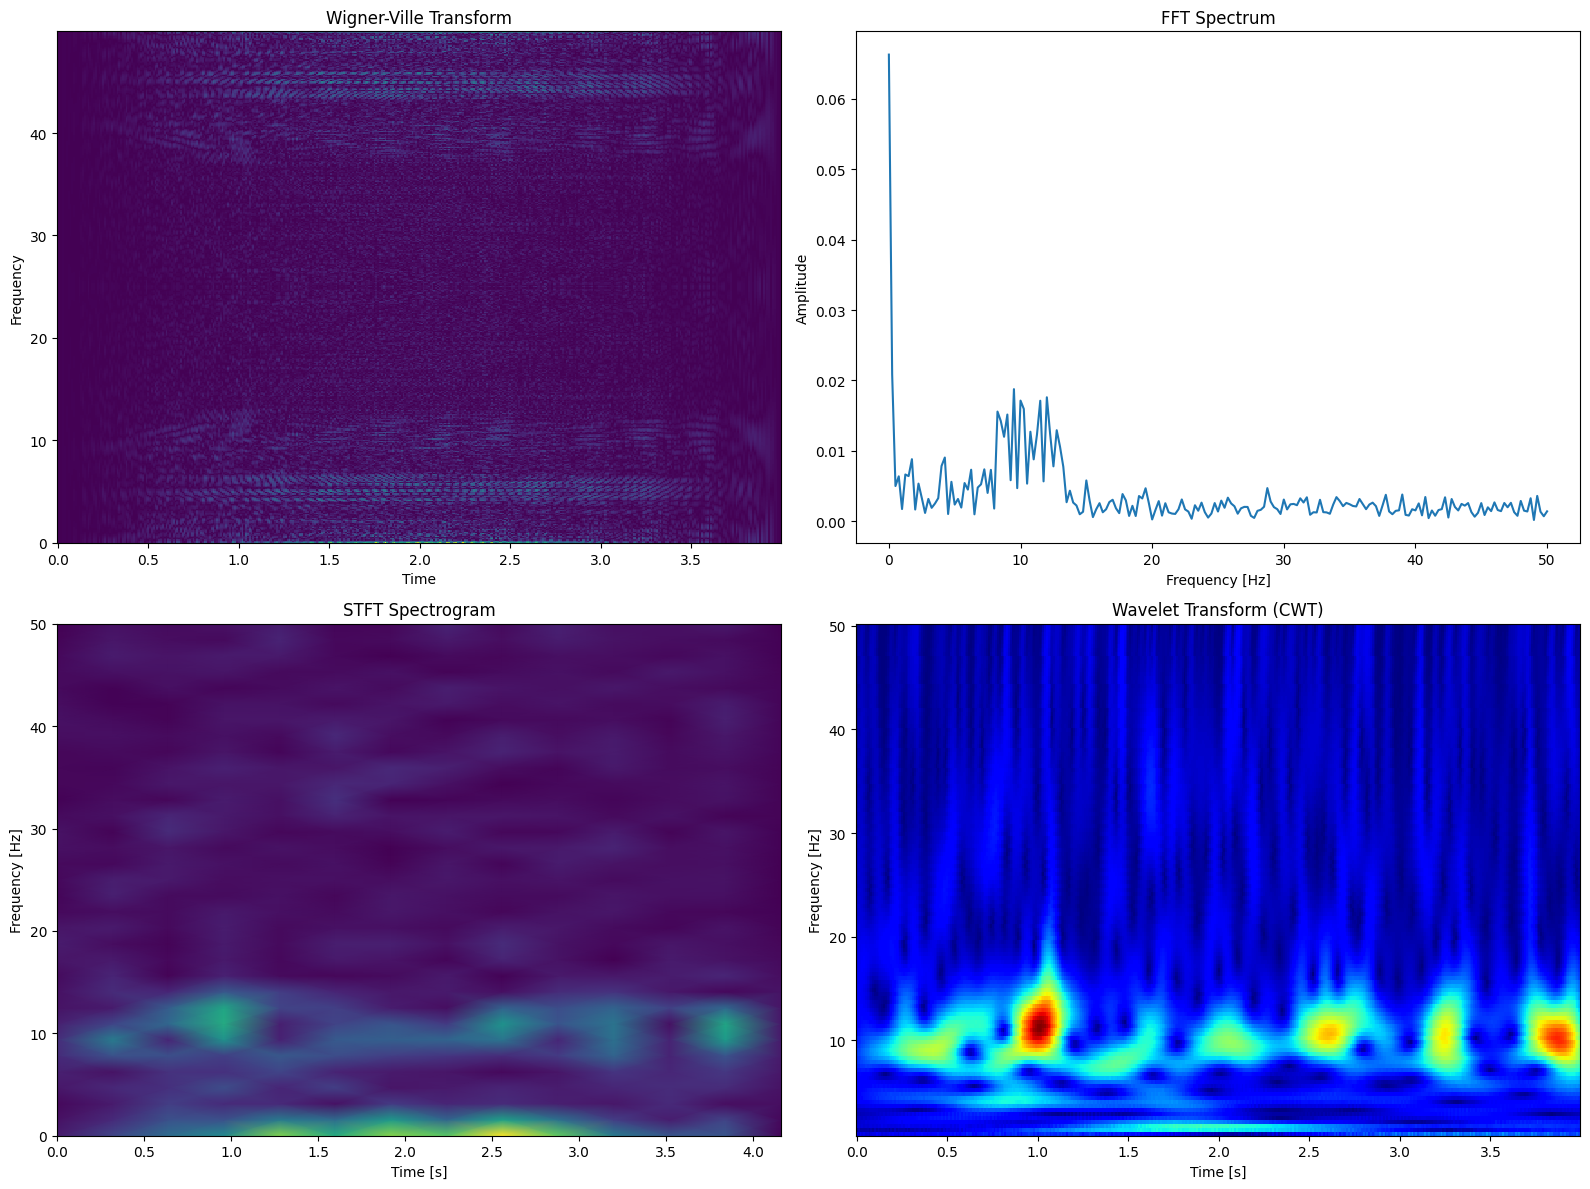

In [15]:
# add offset
offset_signal = base_signal.max()/5 + base_signal

# ht_offset   = analyzer.hilbert_transform(offset_signal, fs=100.0, n_bins=256)
wvt_offset  = analyzer.wvt_transform(offset_signal)
fft_offset  = analyzer.fft_transform(offset_signal, fs=100.0)
stft_offset = analyzer.stft_transform(offset_signal, fs=100.0, nperseg=window_size)
cwt_offset  = analyzer.wt_transform(offset_signal, wavelet='cmor1.5-1.0', fs=100.0)
results_offset = [
    # ht_offset,
    wvt_offset,
    fft_offset,
    stft_offset,
    cwt_offset
]
analyzer.plot_all(offset_signal, results_offset, width=16, height=12, spectrum=False)

In [71]:
import numpy as np
from scipy.signal import hilbert
from scipy.ndimage import gaussian_filter
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_hht_per_imf(imfs, fs=1.0, signal=None, n_freq_bins=200):
    """
    Plot original signal (full bredde) + IMF(t) + Hilbert–Huang spectrum (Plotly)
    """
    n_imfs = len(imfs)
    t = np.arange(imfs.shape[1]) / fs

    # --- Hilbert transform for amplitude/frekvens ---
    analytic = hilbert(imfs, axis=1)
    amp = np.abs(analytic)
    phase = np.unwrap(np.angle(analytic))
    inst_freq = np.diff(phase, axis=1) * fs / (2*np.pi)
    inst_freq = np.abs(inst_freq)
    t_if = t[1:]

    # --- Beregn HHT-spekter for hver IMF ---
    max_freq = np.percentile(inst_freq, 99)
    freq_bins = np.linspace(0, max_freq, n_freq_bins)

    hht_maps = []
    for i in range(n_imfs):
        hht = np.zeros((n_freq_bins, len(t_if)))
        for j in range(len(t_if)):
            f = inst_freq[i, j]
            a = amp[i, j+1]
            if 0 <= f < max_freq:
                idx = np.searchsorted(freq_bins, f)
                hht[idx, j] += a
        hht = gaussian_filter(hht, sigma=1.0)
        hht_maps.append(hht)

    # --- Lag Plotly-layout: toppsignal full bredde + 2 kolonner for IMFs ---
    total_rows = n_imfs + (1 if signal is not None else 0)
    fig = make_subplots(
        rows=total_rows,
        cols=2,
        shared_xaxes=False,
        horizontal_spacing=0.08,
        vertical_spacing=0.04,
        column_widths=[0.45, 0.55],
        specs=[
            [{"colspan": 2}, None] if (signal is not None and r == 0)
            else [{}, {}]
            for r in range(total_rows)
        ],
        subplot_titles=[
            "Original signal" if signal is not None and i == 0 else
            (f"IMF {i if signal is not None else i+1}" if j == 0 else
             f"Hilbert–Huang Spectrum IMF {i if signal is not None else i+1}")
            for i in range(total_rows)
            for j in range(2)
            if not (signal is not None and i == 0 and j == 1)
        ]
    )

    row_offset = 1 if signal is not None else 0

    # --- (1) Original signal over hele toppen ---
    if signal is not None:
        fig.add_trace(
            go.Scatter(x=t, y=signal, mode='lines',
                       line=dict(color='black', width=1.5),
                       name='Original signal'),
            row=1, col=1
        )
        fig.update_yaxes(title_text="Amplitude", row=1, col=1)

    # --- (2) IMF + HHT per IMF ---
    for i in range(n_imfs):
        r = i + row_offset + 1

        # Venstre: IMF
        fig.add_trace(
            go.Scatter(x=t, y=imfs[i], mode='lines',
                       line=dict(color='royalblue'),
                       name=f'IMF {i+1}'),
            row=r, col=1
        )

        # Høyre: Hilbert–Huang spektrum
        fig.add_trace(
            go.Heatmap(
                z=hht_maps[i],
                x=t_if,
                y=freq_bins,
                colorscale='turbo',
                showscale=(i == 0)  # vis kun én fargeskala
            ),
            row=r, col=2
        )

        fig.update_yaxes(title_text="Amplitude", row=r, col=1)
        fig.update_yaxes(title_text="Freq [Hz]", row=r, col=2)

    # --- Layout ---
    fig.update_xaxes(title_text="Time [s]", row=total_rows, col=1)
    fig.update_xaxes(title_text="Time [s]", row=total_rows, col=2)
    fig.update_layout(
        height=260 * total_rows,
        width=1600,
        showlegend=False,
        title="Hilbert–Huang Transform per IMF",
        template="plotly_white",
        margin=dict(t=80, l=50, r=50, b=50),
    )

    fig.show()

emd = EMD()
imfs = emd(base_signal)

plot_hht_per_imf(imfs, fs=100, signal=base_signal)


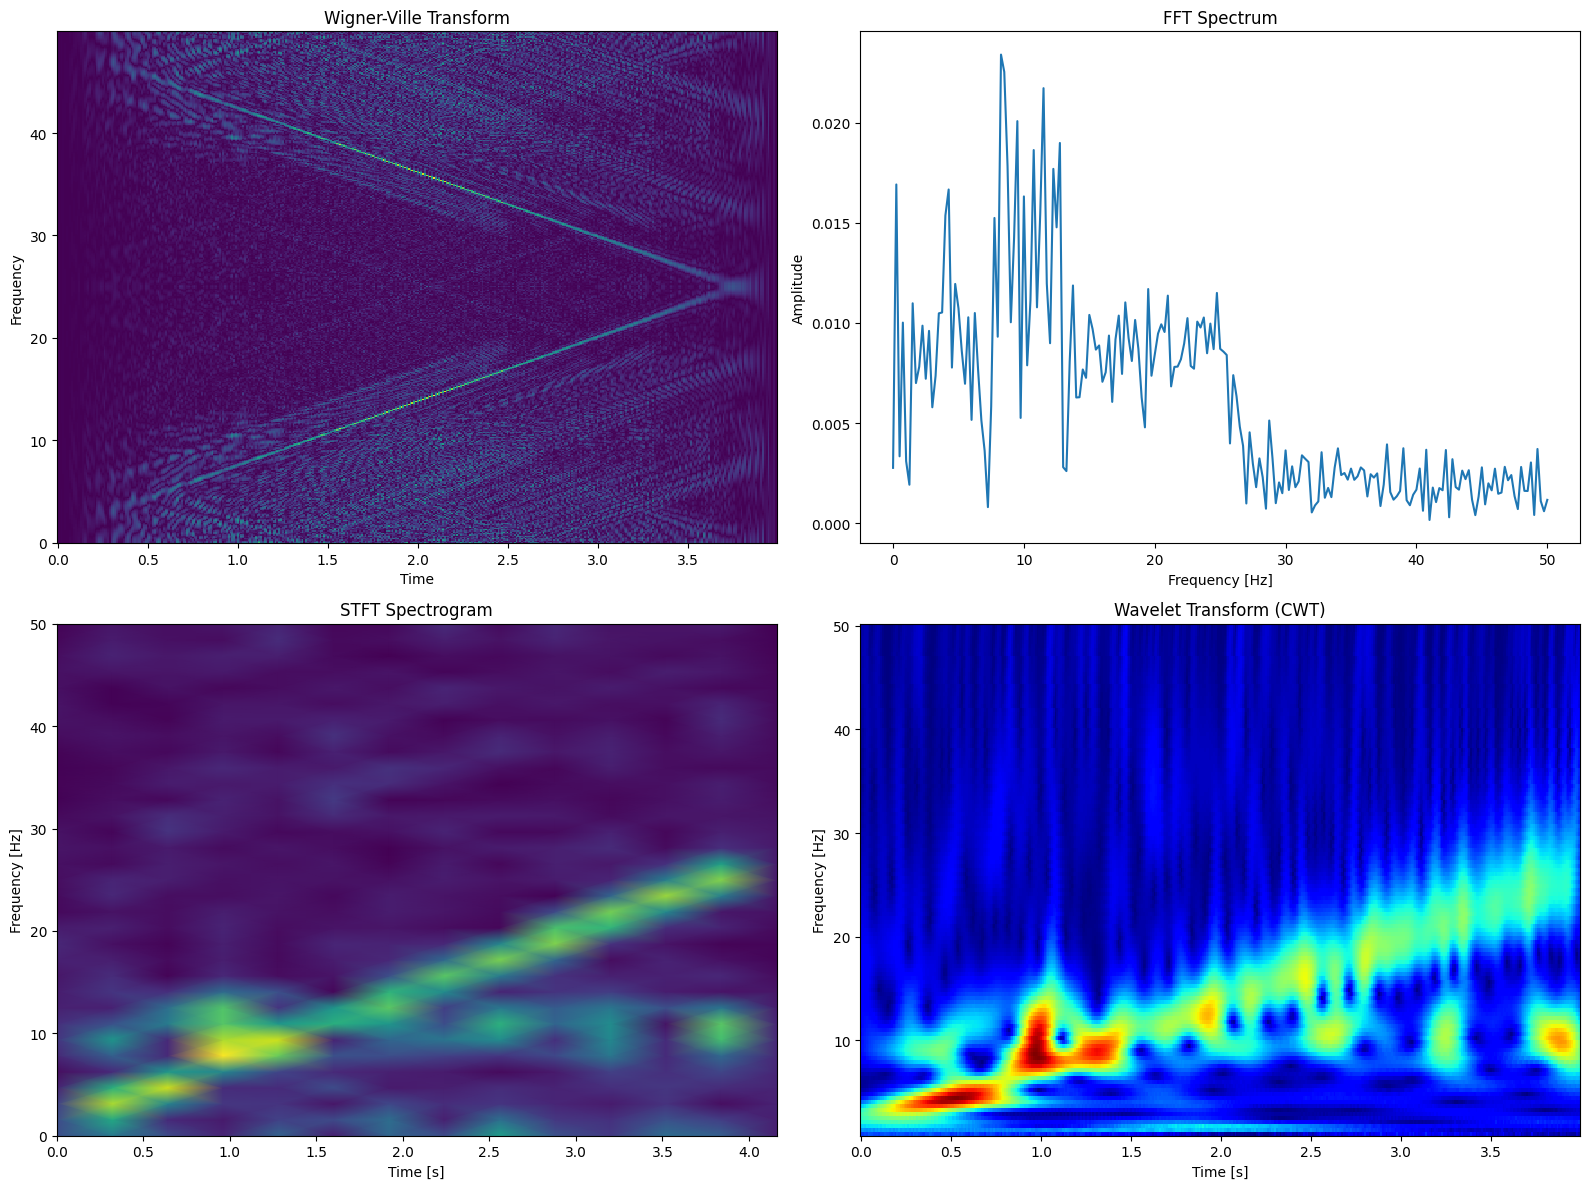

In [16]:
## Add a linearly time variying frquency component
n_chirp = len(base_signal)
t = np.linspace(0, 1, n_chirp)
k = 50 

amplitude = base_signal.max()
chirp = amplitude/2 * np.sin(2 * np.pi * (5 * t + k * t**2)) 

signal_kt = base_signal + chirp
# ht_kt   = analyzer.hilbert_transform(signal_kt, fs=100.0, n_bins=256)
wvt_kt  = analyzer.wvt_transform(signal_kt)
fft_kt  = analyzer.fft_transform(signal_kt, fs=100.0)
stft_kt = analyzer.stft_transform(signal_kt, fs=100.0, nperseg=window_size)
cwt_kt  = analyzer.wt_transform(signal_kt, wavelet='cmor1.5-1.0', fs=100.0)

results_kt = [
    # ht_kt,
    wvt_kt,
    fft_kt,
    stft_kt,
    cwt_kt
]
analyzer.plot_all(signal_kt, results_kt, width=16, height=12, spectrum=False)

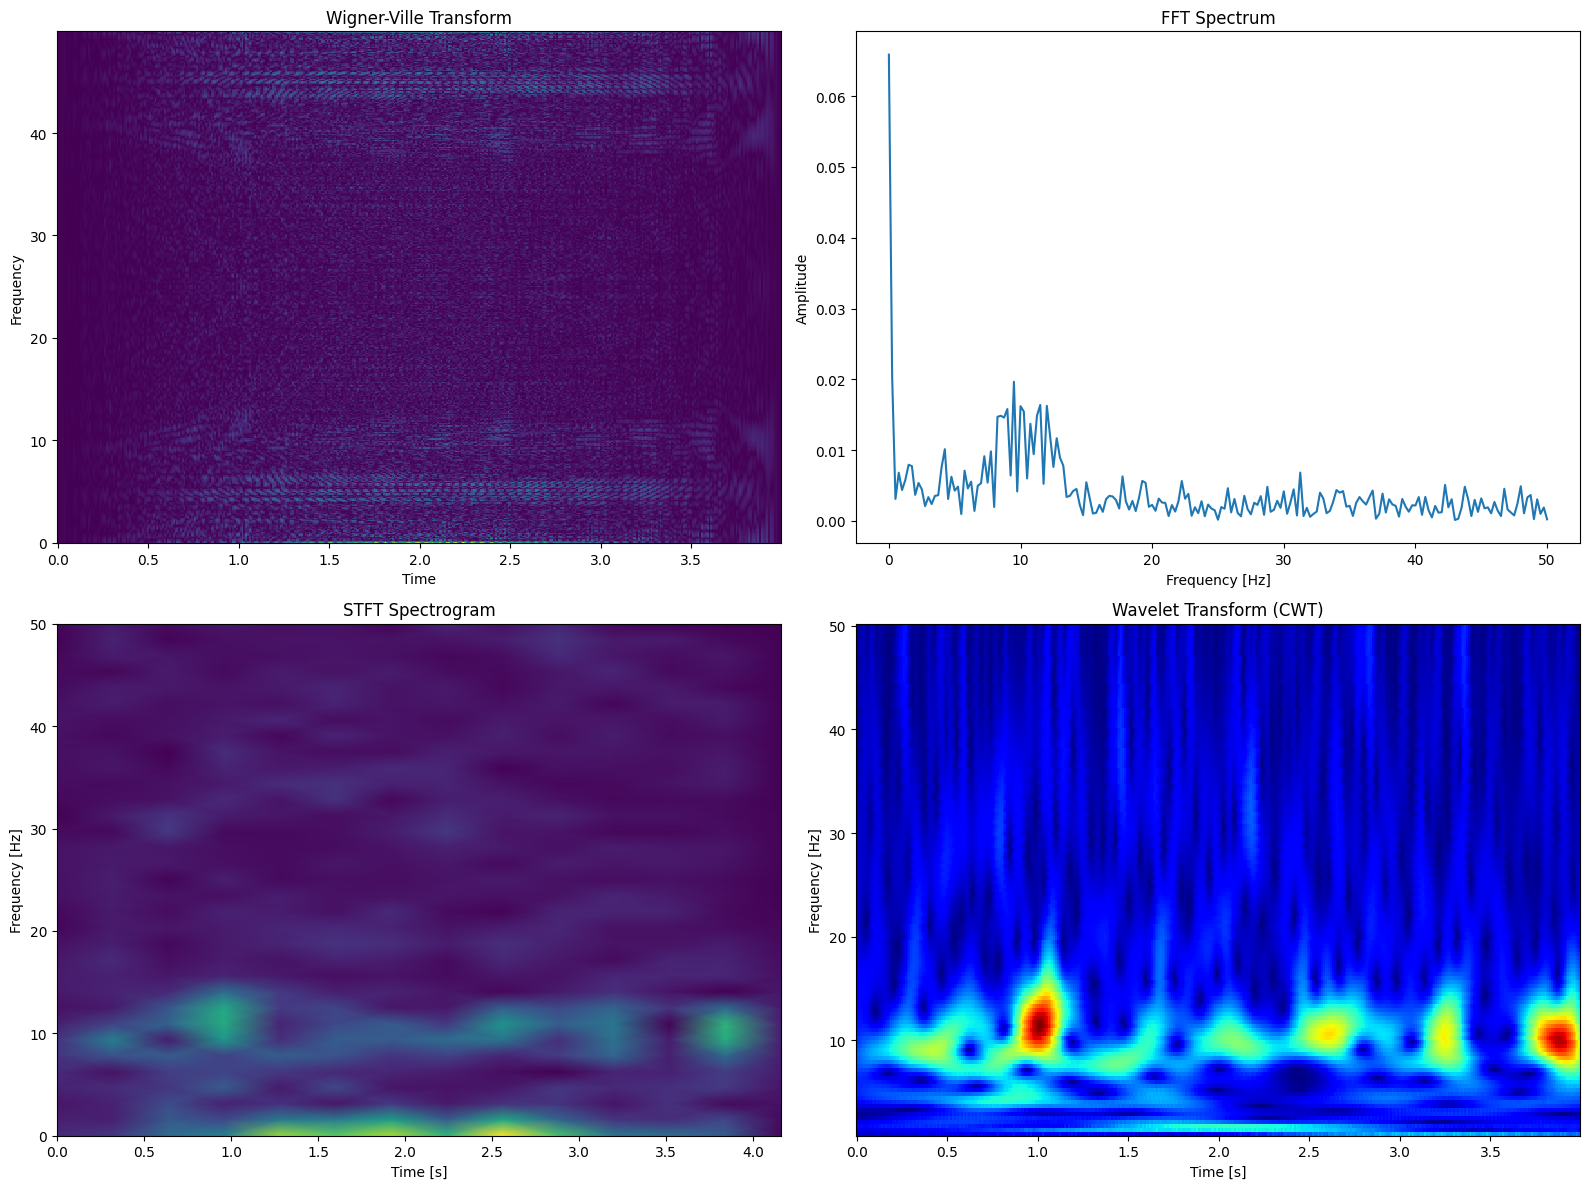

In [17]:
# offset + noise
noisy_offset_signal = offset_signal + noise
# ht_noisy_offset   = analyzer.hilbert_transform(noisy_offset_signal, fs=100.0, n_bins=128)
wvt_noisy_offset  = analyzer.wvt_transform(noisy_offset_signal)
fft_noisy_offset  = analyzer.fft_transform(noisy_offset_signal, fs=100.0)
stft_noisy_offset = analyzer.stft_transform(noisy_offset_signal, fs=100.0, nperseg=window_size)
cwt_noisy_offset  = analyzer.wt_transform(noisy_offset_signal, wavelet='cmor1.5-1.0', fs=100.0)
results_noisy_offset = [
    # ht_noisy_offset,
    wvt_noisy_offset,
    fft_noisy_offset,
    stft_noisy_offset,
    cwt_noisy_offset
]
analyzer.plot_all(noisy_offset_signal, results_noisy_offset, width=16, height=12)